---
categories:
- PPEC
- Ensino
- Estatística
date: 2023-03-16
description: Aula 2 - Notebook sobre Distribuição Normal
image: Distribuição Normal.png
title: "Distribuição Normal"
---

**1) DISTRIBUIÇÃO NORMAL**

A Distribuição Normal também conhecida como Distribuição Gaussiana tem grande importância na Estatística e é definida pela seguinte equação:

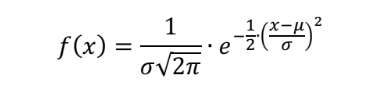

Onde: μ é a média, σ é o desvio-padrão, e e=2,7182 é o número de Euler.

A Distribuição Normal é bem definida quando são fornecidos a média e a variância.
Portanto, f(x) depende de μ e σ² que são os parâmetros da Distribuição Normal.

De forma genérica, o gráfico da distribuição Normal tem o seguinte aspecto:

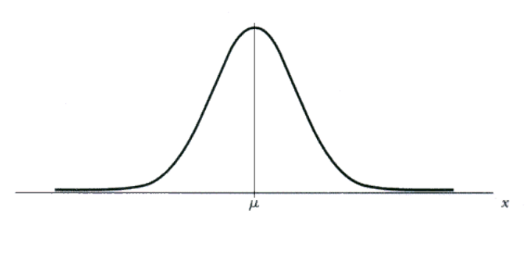

O gráfico se apresenta na forma de um sino, simétrico em relação à ordenada (μ=Mo=Md). O gráfico da distribuição Normal é simétrico em relação à média. Em toda distribuição Normal, a média a mediana e a moda possuem valores iguais.

**- Distribuição Normal Padrão:**

A Distribuição Normal é representada com o símbolo N(μ,σ²). A Normal com média 0 e variância 1, N(0,1) é chamada de Distribuição Normal Padrão ou Distribuição Normal Reduzida.

A quantidade Z numa forma padronizada é dada pela seguinte equação:

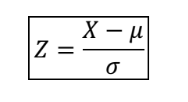





**2) O Método GPR **

O método GPR (Ground Penetrating Radar) é uma ferramenta geofísica que tem por objetivo mapear com alta definição as camadas próximas à superfície bem como as suas descontinuidades, utilizando a emissão de pulsos eletromagnéticos de alta frequência.
A técnica consiste na emissão de pulsos eletromagnéticos de alta frequência no solo através de uma antena transmissora. A velocidade de propagação do pulso depende das propriedades elétricas do meio em que circula.
Ao atingir uma interface entre dois
meios com propriedades elétricas distintas, a onda pode sofrer reflexão, refração ou difração. O sinal refletido ou difratado para a superfície é detectado por uma antena receptora. Imediatamente após a emissão do pulso é iniciada a contagem do tempo para que o sinal retorne para a superfície e seja captado pela antena receptora. O resultado correspondente à reflexão de determinado traço, representa o tempo duplo (em
nanosegundos) do sinal refletido, refratado ou difratado. Esse processo se repete várias vezes, e o conjunto de traços registrados forma o chamado radargrama (DOURADO et al., 2003).


**3) Caracterização de ruídos**

Em um levantamento de dados de GPR, o sinal recebido é uma combinação das reflexões vindas das interfaces eletromagnéticas da subsuperfície e de ruídos ambientais ou provenientes do instrumento no momento em que é feita a aquisição dos dados.

Muitas vezes, assume-se que o ruído aleatório em um traço de GPR segue uma Distribuição Normal com média zero (μ=0). Isso permite aplicar filtros estatísticos para diminuir os ruídos no sinal.




**4) Detecção de Anomalias **

A Distribuição Normal é usada para diferenciar o que é um sinal real e o que é um ruído. Em um radargrama (perfil gerado após aquisição dos dados), a reflexão de objetos (como tubulações, tanques subterrâneos ou falhas geológicas), geram amplitudes que se desviam significativamente da média do ruído.

Se as amplitudes de uma região do perfil de GPR seguem uma Distribuição Normal, pontos que estão além de 2σ ou 3σ, são classificados como anomalias.
Isso é usado em algoritmos de detecção automática de alvozs, onde o software isola pixels cuja intensidades de reflexão têm baixa probabilidade de pertencer à distribuição Normal do ruído circundante.


**5) Análise de atributos textura**

Em estudos de caracterização de pavimentos ou umidade do solo, os geofísicos podem analisar um histograma de amplitudes deuma janela de dados:


*   Se o histograma for perfeitamente Simétrico (Normal): indica um meio relativamente homogêneo;
*   Se o histograma for Assimétrico: pode indicar a presença de múltiplos refletores pequenos (como brita em concreto ou variações de porosidade), sugerindo que a resposta do meio não é puramente aleatória.

**Exemplo do fluxo de trabalho:**
1. Coleta: dados de GPR sobre uma área de solo argiloso;
2. Pré-processamento: aplicação do filtro de ganho (Gain) e filtro Dewow;
3. Cálculo estatístico: calcular a média e o desvio-padrão em uma zona limpa;
4. Isolamento: destacar todas as reflexões que possuem amplitude>3σ. No GPR, essas áreas geralmente correspondem a frentes de infiltração de água ou objetos metálicos enterrados.   




6) Criando um script que simula um sinal de GPR contendo ruído e uma reflexão. Será usada a Distribuição Normal para identificar estatisticamente onde está o objeto enterrado.
O código utiliza a biblioteca numpy para processamento e matplotlib para visualização.

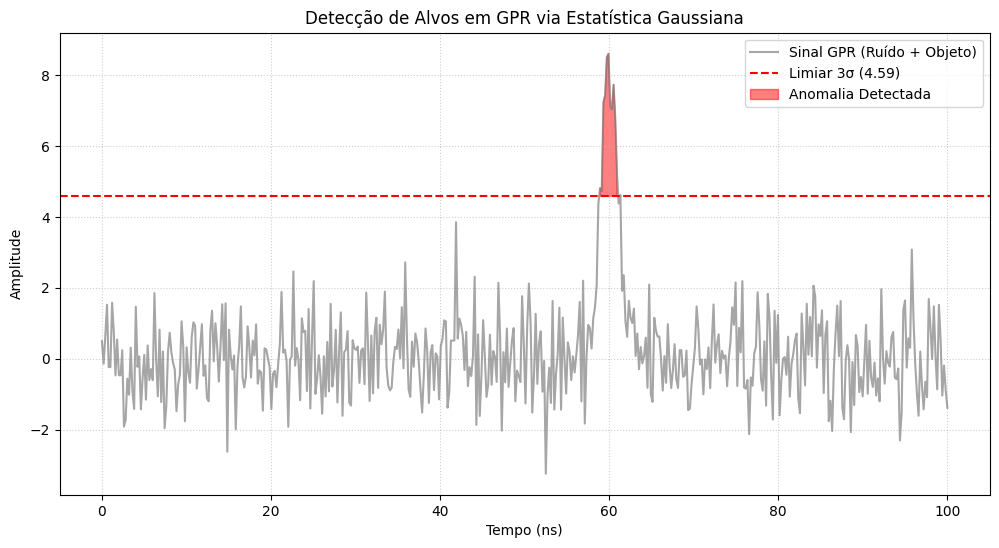

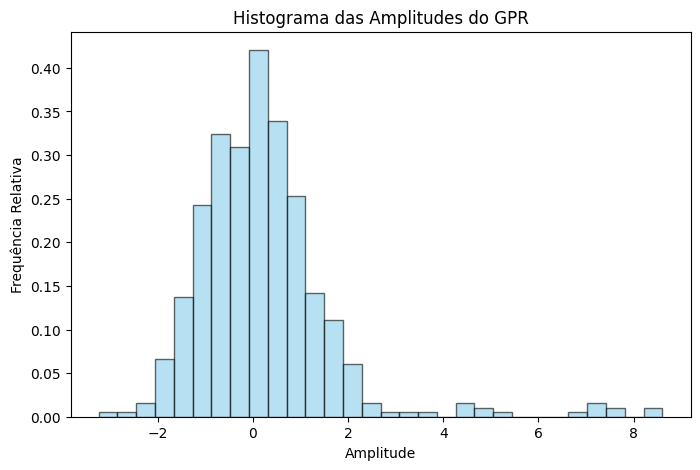

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulação de Dados de GPR
np.random.seed(42)
n_samples = 500
t = np.linspace(0, 100, n_samples) # Eixo do tempo (ns)

# Criamos um ruído de fundo que segue uma Distribuição Normal (Média=0, Desvio Padrão=1)
ruido = np.random.normal(0, 1, n_samples)

# Criamos uma "Anomalia" (um reflexo de tubulação, por exemplo)
# É um pulso de alta amplitude em 60ns
anomalia = 8 * np.exp(-((t - 60)**2) / 2)

# Sinal final recebido pelo GPR
sinal_gpr = ruido + anomalia

# 2. Análise Estatística (Aplicação da Distribuição Normal)
media = np.mean(sinal_gpr)
desvio_padrao = np.std(sinal_gpr)

# Definimos o limiar de detecção (Threshold) baseado na regra 3-sigma
# Valores acima de 3 desvios padrão são estatisticamente anômalos (>99.7% de confiança)
limiar = media + 3 * desvio_padrao

# 3. Visualização
plt.figure(figsize=(12, 6))

# Plot do sinal original
plt.plot(t, sinal_gpr, label='Sinal GPR (Ruído + Objeto)', color='gray', alpha=0.7)

# Destacar a área que excede o limiar da Distribuição Normal
plt.axhline(y=limiar, color='r', linestyle='--', label=f'Limiar 3σ ({limiar:.2f})')
plt.fill_between(t, sinal_gpr, limiar, where=(sinal_gpr > limiar), color='red', alpha=0.5, label='Anomalia Detectada')

plt.title('Detecção de Alvos em GPR via Estatística Gaussiana')
plt.xlabel('Tempo (ns)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 4. Verificação do Histograma
plt.figure(figsize=(8, 5))
plt.hist(sinal_gpr, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.title('Histograma das Amplitudes do GPR')
plt.xlabel('Amplitude')
plt.ylabel('Frequência Relativa')
plt.show()


O código gera dois gráficos principais que ilustram como a estatística ajuda a interpretar os dados de radar:

**1. O Perfil de Amplitude (Traço de GPR)**
Este gráfico mostra o sinal no domínio do tempo (nanossegundos no eixo X).

O sinal do GPR (cinza): Verá uma linha oscilando rapidamente em torno do zero. Esse é o ruído aleatório simulado pela distribuição normal.

O Pulso (Anomalia): Por volta dos 60ns, surge um pico distinto que se eleva muito acima do ruído.

A Linha de Corte (Limiar 3σ): Uma linha tracejada horizontal indica o limite estatístico. Tudo o que ultrapassa essa linha é pintado de vermelho, destacando visualmente onde o "objeto" foi detectado.

**2. O Histograma de Amplitudes**

Este segundo gráfico mostra a distribuição estatística de todos os pontos de dados recolhidos.

A Forma de Sino: A grande maioria dos dados concentra-se entre -3 e 3, formando a curva Gaussiana (Distribuição Normal). Isto representa o ruído de fundo do equipamento.

Os "Outliers": Verá alguns pontos isolados na extremidade direita do gráfico, mais distante da curva Gaussiana. Estes pontos representam as amplitudes elevadas da anomalia (o objeto detectado).